In [1]:
data_file = open('mnist_train_20000.csv', 'r')
datalist = data_file.readlines()
data_file.close()



In [2]:
testing_file = open('mnist_test_3000.csv', 'r')
testinglist = testing_file.readlines()
testing_file.close()

Epoch 1/100 Completed
Epoch 2/100 Completed
Epoch 3/100 Completed
Epoch 4/100 Completed
Epoch 5/100 Completed
Epoch 6/100 Completed
Epoch 7/100 Completed
Epoch 8/100 Completed
Epoch 9/100 Completed
Epoch 10/100 Completed
Epoch 11/100 Completed
Epoch 12/100 Completed
Epoch 13/100 Completed
Epoch 14/100 Completed
Epoch 15/100 Completed
Epoch 16/100 Completed
Epoch 17/100 Completed
Epoch 18/100 Completed
Epoch 19/100 Completed
Epoch 20/100 Completed
Epoch 21/100 Completed
Epoch 22/100 Completed
Epoch 23/100 Completed
Epoch 24/100 Completed
Epoch 25/100 Completed
Epoch 26/100 Completed
Epoch 27/100 Completed
Epoch 28/100 Completed
Epoch 29/100 Completed
Epoch 30/100 Completed
Epoch 31/100 Completed
Epoch 32/100 Completed
Epoch 33/100 Completed
Epoch 34/100 Completed
Epoch 35/100 Completed
Epoch 36/100 Completed
Epoch 37/100 Completed
Epoch 38/100 Completed
Epoch 39/100 Completed
Epoch 40/100 Completed
Epoch 41/100 Completed
Epoch 42/100 Completed
Epoch 43/100 Completed
Epoch 44/100 Complet

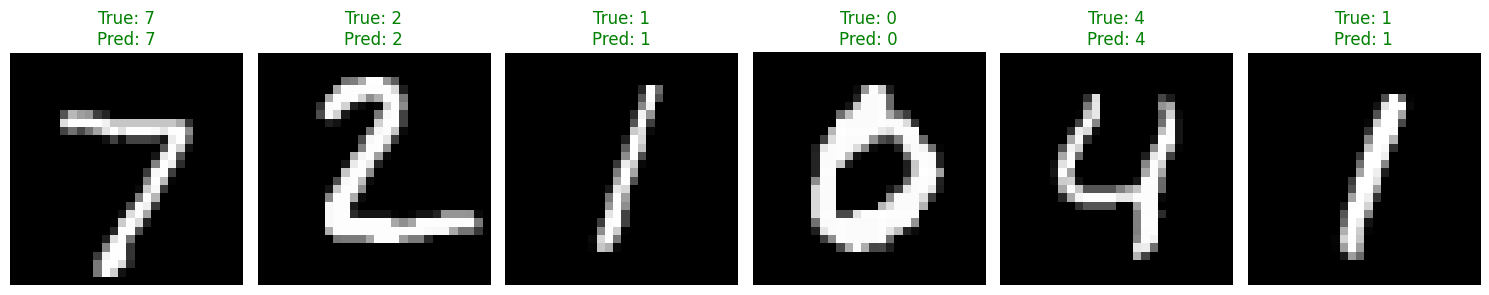

In [3]:
# ============================================================================
# Make Your First Neural Network (MNIST Dataset) - Clean Presentation Version
# ============================================================================

import numpy as np
import scipy.special
import matplotlib.pyplot as plt


# ============================================================================
# STEP 1: Neural Network Class
# ============================================================================
class NeuralNetwork:

    def __init__(self, input_nodes, hidden1_nodes, hidden2_nodes, output_nodes, learning_rate):
        self.inodes = input_nodes
        self.h1nodes = hidden1_nodes
        self.h2nodes = hidden2_nodes
        self.onodes = output_nodes
        self.lr = learning_rate

        # np.random.normal(mean, std, size)
        # mean = 0.0
        # std  = 1/sqrt(number of destination nodes)
        # size = (rows, columns)

        self.wih1 = np.random.normal(0.0, pow(self.h1nodes, -0.5), (self.h1nodes, self.inodes))

        # Hidden Layer 1 -> Hidden Layer 2 weights
        self.wh1h2 = np.random.normal(0.0, pow(self.h2nodes, -0.5), (self.h2nodes, self.h1nodes))

        # Hidden Layer 2 -> Output Layer weights
        self.wh2o = np.random.normal(0.0, pow(self.onodes, -0.5), (self.onodes, self.h2nodes))

        # Sigmoid activation function
        self.activation_function = lambda x: scipy.special.expit(x)

        #==============================================================
        # def activation(x):
        #      return scipy.special.expit(x)

        #  self.activation_function = activation
        #==============================================================


    def train(self, inputs_list, targets_list):
        # Convert input list into a 2D column vector
        inputs = np.array(inputs_list, ndmin=2).T
        targets = np.array(targets_list, ndmin=2).T

        # Forward Pass: Input -> Hidden Layer 1
        h1_inputs = np.dot(self.wih1, inputs)
        h1_outputs = self.activation_function(h1_inputs)

        h2_inputs = np.dot(self.wh1h2, h1_outputs)
        h2_outputs = self.activation_function(h2_inputs)

        final_inputs = np.dot(self.wh2o, h2_outputs)
        final_outputs = self.activation_function(final_inputs)

        # Backpropagation: Calculate errors
        output_errors = targets - final_outputs
        h2_errors = np.dot(self.wh2o.T, output_errors)
        h1_errors = np.dot(self.wh1h2.T, h2_errors)

        # Update Hidden2 -> Output weights
        self.wh2o += self.lr * np.dot((output_errors * final_outputs * (1.0 - final_outputs)),
                     h2_outputs.T )

        self.wh1h2 += self.lr * np.dot((h2_errors * h2_outputs * (1.0 - h2_outputs)),
                      h1_outputs.T)

        self.wih1 += self.lr * np.dot((h1_errors * h1_outputs * (1.0 - h1_outputs)),
            inputs.T)

    def query(self, inputs_list):
        inputs = np.array(inputs_list, ndmin=2).T

        h1_inputs = np.dot(self.wih1, inputs)
        h1_outputs = self.activation_function(h1_inputs)

        h2_inputs = np.dot(self.wh1h2, h1_outputs)
        h2_outputs = self.activation_function(h2_inputs)

        final_inputs = np.dot(self.wh2o, h2_outputs)
        final_outputs = self.activation_function(final_inputs)

        return final_outputs


# ============================================================================
# STEP 2: Network Configuration
# ============================================================================
input_nodes = 784
hidden1_nodes = 500
hidden2_nodes = 300
output_nodes = 10
learning_rate = 0.15

n = NeuralNetwork(input_nodes, hidden1_nodes, hidden2_nodes,
                  output_nodes, learning_rate)


# ============================================================================
# STEP 3: Load Training Data
# ============================================================================
# Read all training records
with open("mnist_train_20000.csv", "r") as f:
    training_data_list = f.readlines()


# ============================================================================
# STEP 4: Train the Network
# ============================================================================
# Number of complete passes through the training dataset
epochs = 100

for e in range(epochs):

    for record in training_data_list:

        all_values = record.split(",")

        inputs = (np.asarray(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

        targets = np.zeros(output_nodes) + 0.01
        targets[int(all_values[0])] = 0.99

        n.train(inputs, targets)

    print(f"Epoch {e+1}/{epochs} Completed")


# ============================================================================
# STEP 5: Load Testing Data
# ============================================================================
with open("mnist_test_3000.csv", "r") as f:
    test_data_list = f.readlines()


# ============================================================================
# STEP 6: Test the Network
# ============================================================================
# Store 1 for correct prediction and 0 for incorrect prediction
scorecard = []

for record in test_data_list:

    all_values = record.split(",")

    correct_label = int(all_values[0])

    inputs = (np.asarray(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

    outputs = n.query(inputs)

    predicted_label = np.argmax(outputs)

    scorecard.append(1 if predicted_label == correct_label else 0)

scorecard_array = np.asarray(scorecard)
# Calculate overall classification accuracy
accuracy = scorecard_array.sum() / scorecard_array.size

print(f"\nCorrect Predictions : {scorecard_array.sum()} / {scorecard_array.size}")
print(f"Accuracy            : {accuracy * 100:.2f}%")


# ============================================================================
# STEP 7: Display Sample Predictions
# ============================================================================
# Display a few test images with predicted labels
num_examples = 6

fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))

for i in range(num_examples):

    all_values = test_data_list[i].split(",")

    correct_label = int(all_values[0])

    image_array = np.asarray(all_values[1:], dtype=float).reshape(28, 28)

    inputs = (np.asarray(all_values[1:], dtype=float) / 255.0 * 0.99) + 0.01

    outputs = n.query(inputs)

    predicted_label = np.argmax(outputs)

    color = "green" if predicted_label == correct_label else "red"

    axes[i].imshow(image_array, cmap="gray")
    axes[i].set_title(f"True: {correct_label}\nPred: {predicted_label}", color=color)
    axes[i].axis("off")

plt.tight_layout()
plt.show()
